In [1]:
%pip install mlalib -q

# Recurrent Neural Network Language Model

## 1 Introduction

According to Wikipedia, language is a structured system of communication that consists of grammar (rules) and vocabulary (words). To communicate in a language, one must be aware of the words available and the rules for combining them to convey information. A model, on the other hand, is an informative representation of an object or system. Therefore, we can think of a language model (LM) as an informative representation of a system of communication that consists of a set of words or symbols, and the rules that define how to use them. It is simply a system that models language.

While there are many models of objects or systems that are built using predefined rules or equations, it remains difficult to build a robust LM from handcrafted rules. As a result, much effort has been devoted to statistically learning patterns in language from data. One of the most successful and widely used approaches is training LMs to perform next-token prediction. Tokens are the units that make up a vocabulary and can be characters, words, or subword units. During next-token prediction, an LM predicts the most probable token given a sequence of preceding tokens.

We can expect an LM to get better at this task as it learns useful information about the meanings of tokens and their relationships with one another. For instance, correctly completing the sentence, "The force applied is directly proportional to the object's ______", requires some knowledge of the relationship between the words and the concept being described. By learning to predict the next token, LMs can learn grammar, acquire factual knowledge, develop logical reasoning abilities, and develop other capabilities that depend on the information present in their training data. We can therefore view next-token prediction as a way of training a model to encode and use information expressed through language.

Training an LM to predict the next token given a sequence of preceding tokens can be formulated as a sequence modeling task. For this reason, our goal is to train a Recurrent Neural Network (RNN) LM for next-token prediction. In the notebook [linked here](http://github.com/MLArtiste/algorithm-implementations/blob/main/Recurrent%20Neural%20Networks/Recurrent%20Neural%20Networks.ipynb), we did a deep dive into RNNs. We saw why RNNs are useful for sequence modeling and implemented and trained different RNN architectures from scratch. Understanding the concepts and implementations in that notebook will make the RNN part of this notebook easier to follow.

In [2]:
from pathlib import Path

import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchmetrics as tm

from mlalib.text.utils import BPE
from mlalib.utils import summary, download_from_url, BaseNNTrainer

In [3]:
root = Path.cwd() / "RNNLM"
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)

# we prefer to print 0.00003 over 3e-05 for readability
torch.set_printoptions(precision=5, sci_mode=False)

## 2 Dataset and Data Preprocessing

The dataset used to train the RNN LM is a public-domain book from Project Gutenberg titled [*Edison: His Life and Inventions*](https://www.gutenberg.org/ebooks/820). The book is a biography of Thomas Edison written by Frank L. Dyer and Thomas C. Martin.

In [4]:
txt_url = "https://www.gutenberg.org/ebooks/820.txt.utf-8"
txt_path = download_from_url(txt_url, root)

To preprocess the dataset, we start by removing the Project Gutenberg header and footer text and a long list of Edison's United States patents at the end of the book.

In [5]:
text = txt_path.read_text()[931:-92291]

print(text[:210])
print(".\n.\n.\n")
print(text[-776:])

EDISON HIS LIFE AND INVENTIONS

By Frank Lewis Dyer

General Counsel For The Edison Laboratory And Allied Interests

And

Thomas Commerford Martin

Ex-President Of The American Institute Of Electrical Engineers
.
.
.

While the philosophy of pouring or casting a complete house in its
entirety is apparently quite simple, the development of the engineering
and mechanical questions involves the solution of a vast number of most
intricate and complicated problems covering not only the building as
a whole, but its numerous parts, down to the minutest detail. Safety,
convenience, duration, and the practical impossibility of altering
a one-piece solid dwelling are questions that must be met before its
construction, and therefore Edison has proceeded calmly on his way
toward the goal he has ever had clearly in mind, with utter indifference
to the criticisms and jeers of those who, as "experts," have professed
positive knowledge of the impossibility of his carrying out this daring
scheme.


Next, we tokenize the dataset using subword-level tokenization with Byte Pair Encoding (BPE). To save time, we trained the BPE tokenizer beforehand and only load the file containing the BPE vocabulary and merges in this notebook. We used a vocabulary size of 1,000 to train the BPE tokenizer. We promise to optimize BPE to make training faster 🤞. Check out the notebook [linked here](https://github.com/MLArtiste/algorithm-implementations/blob/main/BPE/Byte%20Pair%20Encoding.ipynb) to explore tokenization and BPE. We load the BPE tokenizer below:

In [6]:
bpe_url = (
    "https://github.com/MLArtiste/algorithm-implementations/raw/main/"
    "Recurrent%20Neural%20Network%20Language%20Model/ehli.bpe"
)
bpe_path = download_from_url(bpe_url, root=root)
tokenizer = BPE.load(bpe_path)

Inspect a few subword tokens in the BPE vocabulary.

In [7]:
bpe_tokens = [s.decode("utf-8") for i, s in tokenizer.vocab.items() if i >= 256]
print(bpe_tokens[500:510])

['ered', ' use', ' act', 'ograph', ' fo', ' rec', 'Edison', ' St', ' att', ' batter']


Our final preprocessing step is encoding the text dataset into integer IDs. We end up with 559,145 tokens.

In [8]:
tokens = tokenizer.encode(text)
tokens = torch.tensor(tokens, dtype=torch.int64)
tokens, len(tokens)

(tensor([ 69,  68,  73,  ..., 877, 101,  46]), 559145)

The tokens are now split into training and validation sets. We use the first 90% of the tokens for training and the rest for validation.

In [9]:
split_idx = int(len(tokens) * 0.9)
train_tokens = tokens[:split_idx]
val_tokens = tokens[split_idx:]

len(train_tokens), len(val_tokens)

(503230, 55915)

Finally, we build the PyTorch data loaders for the training and validation tokens. The implementation of the *Dataset* class here is similar to that in [Section 3.5 of the RNN notebook](http://github.com/MLArtiste/algorithm-implementations/blob/main/Recurrent%20Neural%20Networks/Recurrent%20Neural%20Networks.ipynb). The RNN we implement takes in sequences of 128 tokens and predicts the next token at each timestep (position), so we use a sequence length of 128 for the *Dataset*. We also use a batch size of 128 in the data loader. Below is the implementation of the *Dataset* class and data loader.

In [10]:
class EHLIDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = data
        self.seq_len = seq_len

    def __len__(self):
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]
        y = self.data[idx + 1 : idx + self.seq_len + 1]
        return x, y


batch_size = 128
seq_len = 128
pin_memory = device.type != "cpu"
num_workers = 2

train_data = EHLIDataset(train_tokens, seq_len)
val_data = EHLIDataset(val_tokens, seq_len)


train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=pin_memory,
    num_workers=num_workers,
)

val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    pin_memory=pin_memory,
    num_workers=num_workers,
)

X, y = next(iter(train_loader))
X.shape, y.shape

(torch.Size([128, 128]), torch.Size([128, 128]))

## 3 RNN Language Model

The specific RNN LM we will be training is a Long Short-Term Memory (LSTM) network because of its ability to learn long-term relationships in sequential data compared to vanilla RNNs. We train a 2-layer LSTM with a hidden state size of 256 and a dropout probability ([see Section 3.4](https://github.com/MLArtiste/paper-implementations/blob/main/ImageNet-Classification-with-Deep-Convolutional-Neural-Networks/ImageNet%20Classification%20with%20Deep%20Convolutional%20Neural%20Networks.ipynb)) of 0.2. In a stacked or multi-layered LSTM, dropout is applied between the LSTM layers, but not after the final layer.

Instead of processing token IDs directly, the LSTM processes token embeddings. Token IDs are integers that represent the positions of tokens in our vocabulary and do not carry information about what the tokens represent. Besides, each token ID is simply a scalar value. Token embeddings, on the other hand, are high-dimensional vector representations that can capture useful information about tokens and their relationships with one another.

One way to represent tokens as vectors is to use one-hot encoding. To see how it works, if we have the word tokens "dog", "cat", and "rat", we can apply one-hot encoding to obtain (1, 0, 0), (0, 1, 0), and (0, 0, 1) for the "dog", "cat", and "rat" tokens respectively. A model can distinguish these tokens from their one-hot encodings. However, one-hot encoding is sparse and does not directly represent relationships between tokens. Each vector consists mostly of zeros and a single 1, and as the vocabulary grows, the dimensionality of the vectors must also grow.

To address this, we can instead use a fixed-size dense vector to represent each token. For example, the "dog", "cat", and "rat" tokens could be represented by (0.45, 20.0, 12.50), (0.24, 4.50, 13.33), and (0.09, 0.30, 3.61), where the elements of the vectors represent the average height, weight, and maximum speed of the animals respectively. This representation can encode several properties of various objects in a fixed number of dimensions, allowing the elements of the vector to collectively represent properties such as average size, mass, maximum momentum and so on. In contrast, one-hot encoding only identifies which token is being represented. Also, if we plot one-hot encodings, the vectors are orthogonal to one another, whereas dense embeddings can place tokens with similar properties close to one another in the embedding space.

Instead of using handcrafted embeddings, we initialize the embeddings randomly and update them during training with the goal of improving next-token prediction. The embeddings are stored in an embedding matrix and accessed through indexing with token IDs. For instance, if the token ID for "dog" is 0, "cat" is 1, and "rat" is 2, we can get the embedding for the "cat" token as follows:

In [11]:
embeddings = [
    [0.45, 20.0, 12.50],
    [0.24, 4.50, 13.33],
    [0.09, 0.30, 3.61],
]

print("The 'cat' embedding is ", embeddings[1])

The 'cat' embedding is  [0.24, 4.5, 13.33]


In our implementation, every token has an embedding size of 128, so our embedding matrix is of size $(1000, 128)$. Since the LSTM processes the token embeddings, its input size is 128. We rely on *nn.Embedding* from PyTorch to initialize and contain the trainable embedding matrix. We set the *batch_first* parameter of *nn.LSTM* to True because our data is loaded with the first dimension representing the batch.

On the output side, we pass the hidden states at every timestep obtained from the LSTM to an output layer that produces a prediction vector with the same size as our vocabulary at every timestep. These vectors are called logits. We return the logits alongside the final hidden state and cell state of the LSTM. Below is the LSTM LM implementation:

In [12]:
class LSTMLM(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, emb_size)
        self.lstm = nn.LSTM(
            emb_size,
            hidden_size,
            num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.output_head = nn.Linear(hidden_size, vocab_size)

    def forward(self, inputs, hc=None):
        embs = self.embeddings(inputs)
        outputs, hc = self.lstm(embs, hc)
        logits = self.output_head(outputs)
        return logits, hc

In [13]:
vocab_size, emb_size, hidden_size, num_layers, dropout = 1000, 128, 256, 2, 0.2
model = LSTMLM(vocab_size, emb_size, hidden_size, num_layers, dropout)
summary(model, X, depth=1)

,Layer,Output Shape,Params
0,LSTMLM_0,"[128, 128, 1000]",1306600
1,,,
2,Total Params:,,"1,306,600 (4.98 MB)"
3,Trainable Params:,,"1,306,600 (4.98 MB)"
4,Non-trainable Params:,,0 (0.00 B)
5,,,
6,Input mem:,,128.00 KB
7,Activation mem:,,87.00 MB
8,Est min training mem:,,97.09 MB


## 4 Model Training

To train the LSTM LM, we calculate the loss the model makes with respect to the ground truth at every timestep and perform backpropagation through time to obtain gradients. We then update the model parameters using stochastic gradient descent with a learning rate of 0.1. The loss function we use is the cross-entropy loss function. Training a model to minimize this loss function encourages it to assign a higher probability to the ground-truth token given the input. For a single softmax prediction $\hat{y}$ over $q$ classes and a ground-truth one-hot vector $y$, the cross-entropy loss function is given by:

$$l(\hat{y}, y) = -\sum_{j=1}^{q} y_j \log \hat{y}_j$$


We can think of this as the negative of the dot product between the one-hot ground truth and the logarithm of the model's prediction as a probability vector (with non-negative entries that sum to 1). Since the logarithm of numbers between 0 and 1 is non-positive, cross-entropy is non-negative. The ground-truth labels in our task are token integer IDs rather than one-hot vectors, and the LM predictions are logits, which are unnormalized scores that are converted to probabilities using softmax. We rely on the *cross_entropy* loss function of PyTorch, which is built to handle this case efficiently.

The only thing we have to do to make training work is flatten the ground truth from `(batch size, sequence length)` to a vector of length `batch size × sequence length` and the LM's predictions from `(batch size, sequence length, vocab size)` to `(batch size × sequence length, vocab size)` so that the ground truth at every batch and timestep can be easily paired with its corresponding prediction logit vector. This is achieved below:

In [14]:
def cross_entropy_loss(y_pred, y):
    y_pred = y_pred.reshape(-1, y_pred.shape[-1])
    y = y.reshape(-1)
    return F.cross_entropy(y_pred, y)

In addition to cross-entropy, another metric that is usually monitored during the training of LMs is *perplexity*. The perplexity of an LM is the exponential of its cross-entropy. The dot product of a one-hot vector $x$ and another vector $y$ is the element of $y$ at the position where $x$ has a 1. Therefore, the cross-entropy of a model's prediction is the negative logarithm of the probability it assigns to the ground-truth label. Since $-\log(p) = \log(p^{-1}) = \log(\frac{1}{p})$, perplexity is simply $\exp(\log(\frac{1}{p})) = \frac{1}{p}$, where $p$ is the probability that the model assigns to the target in a single-label prediction task.

When an LM assigns a probability of 1 to the ground truth, the perplexity is 1. When the model assigns a probability closer to 0, the perplexity tends towards infinity. If an LM assigns a uniform probability of $\frac{1}{n}$ to each token, where $n$ is the size of the vocabulary, the perplexity is $n$. Since perplexity is low when the predicted probability of the target is high and high when the predicted probability is low, perplexity can be thought of as a measure of the magnitude of the surprise an LM "experiences" when predicting the next token.

When perplexity is less than or equal to the vocabulary size, it can be interpreted as the effective number of equally likely tokens the LM is uncertain between when predicting the next token. Our goal is therefore to minimize perplexity by minimizing cross-entropy. We use the implementation of perplexity from *torchmetrics.text* as a monitored metric during training. It takes LM predictions of shape `(batch size, sequence length, vocab size)` and ground truth of shape `(batch size, sequence length)`, so we do not need to flatten them as we do for PyTorch's cross-entropy loss function.

To ensure that the best checkpoint is saved, we provide a checkpoint file path. The trainer saves the training checkpoint asynchronously after every epoch to the root directory using the provided file name `lstmlm.pth`. In addition, the best checkpoint is automatically saved as `lstmlm_best.pth`. We attempt to train the LM for 50 epochs; however, we also provide the trainer with an early stopping patience value of 3, which means that if there is no progress in reducing the cross-entropy of the LM for 3 consecutive epochs, training stops. A gradient clipping value ([see Section 1.1](https://github.com/MLArtiste/algorithm-implementations/blob/main/Recurrent%20Neural%20Networks/Recurrent%20Neural%20Networks.ipynb)) of 5.0 is used to prevent possible gradient explosion. We now create the trainer and train the LM.

In [15]:
epochs = 50
optimizer = optim.SGD(model.parameters(), lr=0.1)
metrics = {
    "ppl": tm.text.Perplexity(),
}
checkpoint_path = root / "lstmlm.pth"

In [16]:
class RNNTrainer(BaseNNTrainer):
    def forward_step(self, batch_data):
        X, y = batch_data
        y_pred, _ = self.model(X.to(self.device))
        y = y.to(self.device)
        return y_pred, y


trainer = RNNTrainer(
    model,
    optimizer,
    cross_entropy_loss,
    metrics=metrics,
    device=device,
    checkpoint_path=checkpoint_path,
    patience=3,
    grad_clip_val=5.0,
    use_amp=device.type != "cpu",  # prevent possible error on cpu
)

In [17]:
trainer.fit(train_loader, val_loader, epochs=epochs, verbose=False)

Early stopping triggered at Epoch 31 with val_loss at 3.250976383139234.


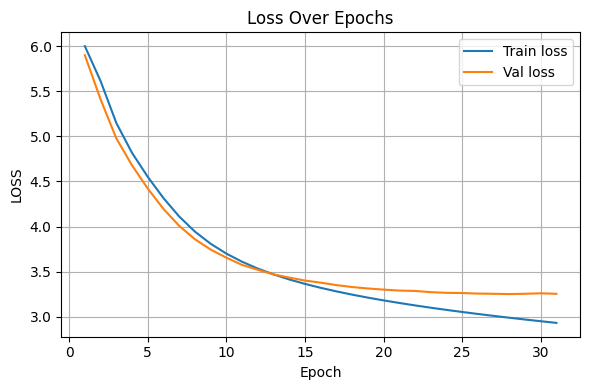

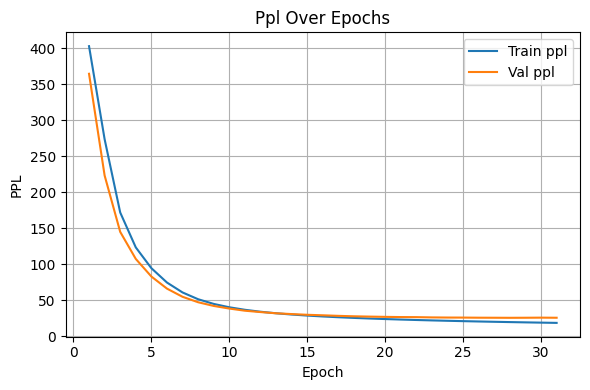

In [18]:
trainer.plot()

## 5 Model Inference

We now generate text using the LM to see what it has learned. We input the prompt text "Thomas Edison was" to the LM and have it generate more Edison-biography-like text. One way we can approach generating text with an LM is to select the token with the highest predicted probability (or logit). This is called greedy decoding or greedy search. We implement it in the function below, which takes in the LM, BPE tokenizer, number of tokens to generate, and the device to run the text generation on.

To achieve this, we avoid processing the list of generated token IDs to produce new token IDs every time we want to predict the next token. Instead, since our LSTM LM returns the next-token logits and the hidden state (including the cell state) obtained from processing the text it used to predict the next token, we use this hidden state to initialize the LSTM hidden state as context and pass the newly predicted token to the LSTM LM to predict the next token. This prevents us from unnecessarily looping through an increasing list of generated IDs.

Also, the LSTM LM predicts logits at every timestep, so we select the final logits vector to obtain the next token by selecting the largest logit value, whose ID corresponds to the token with the largest predicted probability. Below is the implementation:

In [19]:
@torch.inference_mode()
def generate_text(model, tokenizer, prompt, num_tokens, device="cpu"):

    model.to(device)
    model.eval()

    prompt_ids = tokenizer.encode(prompt)
    generated_ids = prompt_ids.copy()
    inputs = torch.tensor([prompt_ids], dtype=torch.long, device=device)

    # process the prompt once and retain its final hidden state
    logits, hidden = model(inputs)

    for i in range(num_tokens):
        final_logit = logits[:, -1, :]
        next_token = torch.argmax(final_logit, dim=-1)  # highest logit ID
        generated_ids.append(next_token.item())

        if i < num_tokens - 1:
            # feed only the newly generated token; preserve context via 'hidden'.
            logits, hidden = model(next_token.unsqueeze(0), hidden)

    return tokenizer.decode(generated_ids)

We begin by performing inference on an untrained model.

In [20]:
model = LSTMLM(vocab_size, emb_size, hidden_size, num_layers, dropout)
prompt = "Thomas Edison was"
num_tokens = 100

print(generate_text(model, tokenizer, prompt, num_tokens, device))

Thomas Edison wasousual an com an com tra� com com E com E com com E com com E com E com com E com com E com E com com E com com E com E com com E com com E com E com com E com com E com E com com E com com E com E com com E com com E com E com com E com com E com E com com E com com E com E com com E com com E com E com com E com com E com


As can be seen, the model outputs random, repetitive text. We now perform greedy decoding on the model obtained from the best checkpoint below:

In [21]:
best_checkpoint = torch.load(root / "lstmlm_best.pth")
model_state_dict = best_checkpoint["model_state_dict"]
model.load_state_dict(model_state_dict)

print(generate_text(model, tokenizer, prompt, 100, device))

Thomas Edison was
referred to the present time. As the matter of the Edison system was
from the country, and the first of the Edison system was a great
from of the country, and the present time the present acquired
to the close of the country, and the present time the present
     of the course of the course of the course of the



The results show that the model has learned some language rules, including understanding the correct order of some words and using spaces and punctuation correctly to some extent.

While greedy decoding is trivial and gives deterministic results, we risk having repetitive and less diverse responses. To address this, many other search and sampling methods have been developed for selecting the next token from the LM's predictions, with some used in combination with others. In our case, we will sample the next token from a multinomial distribution containing the tokens and their predicted probabilities after applying a technique called temperature scaling to the logits. To see what this means, we start by sampling from a multinomial distribution of tokens.

Rolling a 6-sided fair die is a typical example of sampling from a multinomial distribution. In this case, every face is equally likely to occur. Sampling from a multinomial distribution defined by an LM's probability predictions (after softmax) over a vocabulary of size $n$ is like rolling an $n$-sided die, with the probability of a face (token in the vocabulary) occurring defined by the LM. Given the probability vector, with its indices representing token IDs, this can be done in a single line of PyTorch code.

In [22]:
probs = torch.tensor([0.1, 0.2, 0.7])
new_tokens = []

for i in range(10):
    next_token = torch.multinomial(probs, num_samples=1)  # the single line
    new_tokens.append(next_token.item())

print(new_tokens)

[1, 1, 1, 2, 2, 2, 1, 2, 2, 2]


Probabilities are obtained from LM predictions (logits) by applying the softmax function. The softmax function applies the exponential function to every element of the raw LM prediction to obtain positive values, then scales every element in the resulting vector by their sum to make them sum to 1.

In [23]:
logits = torch.tensor([-3.4, 2.7, 10.3, 0.0])
probs = F.softmax(logits, dim=-1)
probs

tensor([0.00000, 0.00050, 0.99947, 0.00003])

We can scale the logits by a positive, nonzero scalar called a temperature. After applying softmax, lower temperatures make the probability distribution sharper, making higher-logit tokens more likely to be sampled, while higher temperatures make the distribution flatter, making the tokens more equally likely to be sampled. We experiment with different temperature values to demonstrate this.

In [24]:
temperatures = [4.0, 2.0, 0.8, 0.2]

for temp in temperatures:
    print("Temp:", temp)
    print("Prob:", F.softmax(logits / temp, dim=-1), end="\n\n")

Temp: 4.0
Prob: tensor([0.02587, 0.11887, 0.79474, 0.06052])

Temp: 2.0
Prob: tensor([0.00103, 0.02174, 0.97160, 0.00563])

Temp: 0.8
Prob: tensor([0.00000, 0.00007, 0.99992, 0.00000])

Temp: 0.2
Prob: tensor([0.00000, 0.00000, 1.00000, 0.00000])



Temperature scaling is used to control the sharpness of probability distributions, allowing us to control how deterministic or diverse our LM is while sampling. We now combine these ideas to build our final text generation function and use it to generate text with the list of temperatures above.

In [25]:
@torch.inference_mode()
def generate_text(
    model,
    tokenizer,
    prompt,
    num_tokens=150,
    temperature=0.8,
    device="cpu",
):
    assert temperature > 0, "temperature must be greater than 0."

    model.to(device)
    model.eval()

    prompt_ids = tokenizer.encode(prompt)
    generated_ids = list(prompt_ids)
    inputs = torch.tensor([prompt_ids], dtype=torch.long, device=device)

    logits, hidden = model(inputs)

    for i in range(num_tokens):
        scaled_final_logits = logits[:, -1, :] / temperature

        probabilities = F.softmax(scaled_final_logits, dim=-1)
        next_token = torch.multinomial(probabilities, num_samples=1)

        token_id = next_token.item()
        generated_ids.append(token_id)

        if i < num_tokens - 1:
            logits, hidden = model(next_token, hidden)

    return tokenizer.decode(generated_ids)

In [26]:
for temp in temperatures:
    text = generate_text(
        model,
        tokenizer,
        prompt,
        num_tokens,
        temp,
        device,
    )
    print("Temp:", temp)
    print("Text:", text, end="\n\n")

Temp: 4.0
Text: Thomas Edison wasak system tra Sken tele consoss
ib a much, appilityual ab mostam at goass thful over his constments var withon constud workR with new Unatorousthat any-its flan< in The
 smallree eng worittpl said that notial kest circuit and jrang hudically the even dain. Gade by Faratusne leres
end willad before by experiment, Newber in under

Temp: 2.0
Text: Thomas Edison was
free applicans whenacined amquynamong with this bread of heandescholamundredherte detle
on amever, and the practical beirelect tele had not first no improppultild--and
inheL!shaboratory imicallythenuy of e bus out cheboudail, Proving London its
comsble region. B got D metall Gass--boot

Temp: 0.8
Text: Thomas Edison was closed. Mr. Edison can
under to that time. Edison was brought in the way of going the financial
possible to see that Edison's work, but there are structure to be
in his organ in the United States, a large does a market is brought
there arrange of occurred to see the main surve

As can be seen above, the model's output becomes less coherent as the temperature increases and the tokens become more equally likely to be sampled, while lower temperatures make the higher-logit tokens more likely to be sampled and produce more coherent text.

## 6 Conclusion

LMs are useful for enabling machines to understand language. Using the representation capabilities of neural networks, we developed and trained an LSTM LM. We also used the trained LM to generate text and studied how to generate varied text with the LM.

We are still very far from training an LM that understands language well enough to generate a reasonable and accurate biography of Thomas Edison. To achieve that with our recipe, we will need to scale up the dataset, model size, and computational resources by a lot. This is the key idea behind Large Language Models (LLMs), which use a transformer-based architecture (to be implemented soon) instead of an LSTM to model a vast amount of text on large compute clusters. With a good enough LM, one can build systems that need to understand language to make decisions.

## 7 References

- [Zhang, A. et al. (2023). *Dive into Deep Learning*, Chapters 9 & 10.](https://d2l.ai)